# Détection de sites web de phishing

### Objectif
L'objectif de ce notebook est de construire un pipeline complet et lisible pour la détection de phishing :

1. charger et comprendre le dataset ;
2. nettoyer et préparer les données ;
3. comparer plusieurs scénarios de modélisation ;
4. retenir le **cas 4** comme scénario final ;
5. optimiser le modèle final ;
6. sauvegarder les artefacts pour le projet de déploiement.

### Point méthodologique important
Le **cas 4** est la référence finale du projet.  
Les colonnes suivantes sont exclues du pipeline final, car elles ne doivent pas être utilisées dans l'inférence temps réel :

- `URLSimilarityIndex`
- `DomainTitleMatchScore`
- `URLTitleMatchScore`
- `TLDLegitimateProb`
- `URLCharProb`
- `CharContinuationRate`

In [1]:
# Décommente cette ligne si LightGBM n'est pas encore installé
# !pip install lightgbm -q

## 1. Importation des bibliothèques et configuration

In [2]:
from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    StratifiedGroupKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Configuration chargée.")

Configuration chargée.


## 2. Chargement du dataset


In [3]:
df = pd.read_csv(r"C:\PhiUSIIL_Phishing_URL_Dataset.csv", encoding="latin1")
print(f"Shape initiale : {df.shape}")
df.head()

Shape initiale : (235795, 56)


,ï»¿FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,Ã Â¸âÃ Â¹ËÃ Â¸Â²Ã Â¸Â§Ã Â¸ÂªÃ Â¸â Ã Â¸â...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃÂ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃÂ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


## 3. Compréhension du dataset

In [4]:
print("Informations générales")
display(df.info())

print("\nAperçu des types de colonnes :")
display(df.dtypes.value_counts())

print("\nValeurs manquantes par colonne (top 20) :")
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values.head(20))

Informations générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ï»¿FILENAME                 235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int6

None


Aperçu des types de colonnes :


int64      41
float64    10
object      5
Name: count, dtype: int64


Valeurs manquantes par colonne (top 20) :


ï»¿FILENAME             0
URL                     0
URLLength               0
Domain                  0
DomainLength            0
IsDomainIP              0
TLD                     0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
URLCharProb             0
TLDLength               0
NoOfSubDomain           0
HasObfuscation          0
NoOfObfuscatedChar      0
ObfuscationRatio        0
NoOfLettersInURL        0
LetterRatioInURL        0
NoOfDegitsInURL         0
DegitRatioInURL         0
dtype: int64

Distribution de la cible :


label
0    100945
1    134850
Name: count, dtype: int64

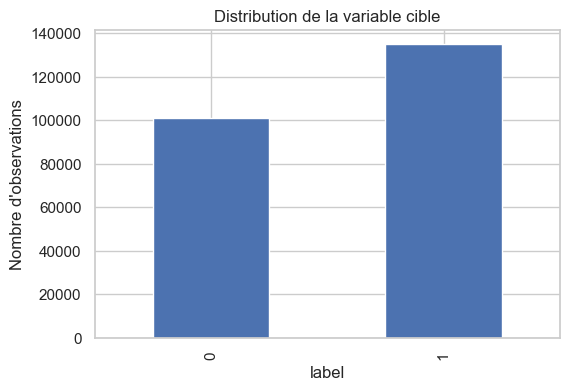

Pourcentage par classe :


label
0    42.81
1    57.19
Name: proportion, dtype: float64

In [5]:
print("Distribution de la cible :")
label_counts = df["label"].value_counts().sort_index()
display(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Distribution de la variable cible")
plt.xlabel("label")
plt.ylabel("Nombre d'observations")
plt.show()

label_percent = df["label"].value_counts(normalize=True).sort_index() * 100
print("Pourcentage par classe :")
display(label_percent.round(2))

In [6]:
print("Quelques statistiques descriptives sur les colonnes numériques :")
display(df.describe(include="number").T.head(20))

Quelques statistiques descriptives sur les colonnes numériques :


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6097.000000
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,110.000000
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,100.000000
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,0.522907
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,0.090824
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,13.000000
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,10.000000
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000


## 4. Nettoyage et préparation des données

In [7]:
TARGET_COL = "label"

TEXT_COLS = ["FILENAME", "URL", "Domain", "Title"]
BASE_DROP_COLS = TEXT_COLS + [TARGET_COL]

SUSPECT_COLS = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb",
    "CharContinuationRate"
]

print("Colonnes texte :", TEXT_COLS)
print("Colonnes suspectes à exclure du cas strict 4 :")
for col in SUSPECT_COLS:
    print("-", col)

Colonnes texte : ['FILENAME', 'URL', 'Domain', 'Title']
Colonnes suspectes à exclure du cas strict 4 :
- URLSimilarityIndex
- DomainTitleMatchScore
- URLTitleMatchScore
- TLDLegitimateProb
- URLCharProb
- CharContinuationRate


In [8]:
exact_duplicates = df.duplicated().sum()

feature_cols_all = [col for col in df.columns if col != TARGET_COL]
feature_duplicates = df[feature_cols_all].duplicated().sum()

print("Nombre de doublons exacts :", exact_duplicates)
print("Nombre de doublons sur les features :", feature_duplicates)

df_nodup = df.drop_duplicates().reset_index(drop=True)

print("\nShape avant suppression :", df.shape)
print("Shape après suppression  :", df_nodup.shape)

Nombre de doublons exacts : 0
Nombre de doublons sur les features : 0

Shape avant suppression : (235795, 56)
Shape après suppression  : (235795, 56)


Top 15 des corrélations absolues avec la cible :


,abs_correlation
URLSimilarityIndex,0.860358
HasSocialNet,0.784255
HasCopyrightInfo,0.743358
HasDescription,0.690232
IsHTTPS,0.609132
DomainTitleMatchScore,0.584905
HasSubmitButton,0.578561
IsResponsive,0.548608
URLTitleMatchScore,0.539419
SpacialCharRatioInURL,0.533537


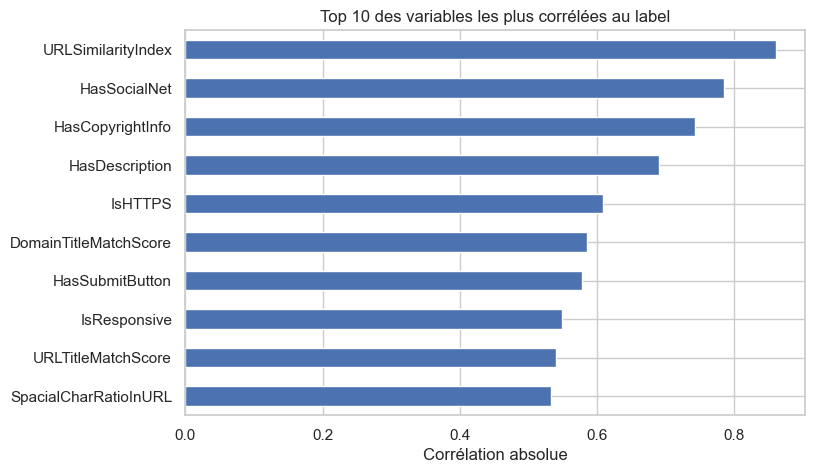

In [9]:
# Corrélations les plus fortes avec la cible
num_cols = df_nodup.select_dtypes(include="number").columns.tolist()

corr_with_label = (
    df_nodup[num_cols]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
)

print("Top 15 des corrélations absolues avec la cible :")
display(corr_with_label.head(15).to_frame("abs_correlation"))

plt.figure(figsize=(8, 5))
corr_with_label.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 des variables les plus corrélées au label")
plt.xlabel("Corrélation absolue")
plt.show()

## 5. Les fonctions de la modélisation

Des fonctions pour :
- construire les pipelines ;
- entraîner les modèles ;
- calculer les métriques ;
- comparer les résultats.

In [10]:
def build_models(X_df):
    """Construit des pipelines simples à partir des types de colonnes."""
    num_cols = X_df.select_dtypes(include="number").columns.tolist()
    cat_cols = X_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    linear_preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    models = {
        "Logistic Regression": Pipeline(steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE
            ))
        ]),
        "Random Forest": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "LightGBM": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=RANDOM_STATE
            ))
        ])
    }
    return models


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Entraîne un modèle et retourne les métriques principales."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }


def run_experiment(X_train, X_test, y_train, y_test, experiment_name):
    """Lance les trois modèles sur un scénario donné."""
    print(f"\n===== {experiment_name} =====")
    results = []

    for model_name, model in build_models(X_train).items():
        print("Entraînement :", model_name)
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test, model_name)
        results.append(metrics)

    results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)
    return results_df


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

## 6. Définition des scénarios

Nous allons comparer 4 cas :

- **Cas 1** : toutes les features, split aléatoire ;
- **Cas 2** : toutes les features, split par domaine ;
- **Cas 3** : sans les colonnes suspectes, split aléatoire ;
- **Cas 4** : sans les colonnes suspectes, split par domaine.

### Cas 1 — Toutes les features + split aléatoire

In [11]:
X_case1 = df_nodup.drop(columns=BASE_DROP_COLS, errors="ignore")
y_case1 = df_nodup[TARGET_COL]

X_train_case1, X_test_case1, y_train_case1, y_test_case1 = train_test_split(
    X_case1,
    y_case1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_case1
)

print("Train shape :", X_train_case1.shape)
print("Test shape  :", X_test_case1.shape)

results_case1 = run_experiment(
    X_train_case1, X_test_case1, y_train_case1, y_test_case1,
    "Cas 1 - Random Split"
)
results_case1

Train shape : (188636, 52)
Test shape  : (47159, 52)

===== Cas 1 - Random Split =====
Entraînement : Logistic Regression
Entraînement : Random Forest
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5254
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 237
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,1.000000,1.000000,1.0,1.000000,1.0,1.0
1,Random Forest,0.999936,0.999889,1.0,0.999944,1.0,1.0
2,Logistic Regression,0.999873,0.999778,1.0,0.999889,1.0,1.0


### Cas 2 — Toutes les features + split par domaine

In [12]:
X_case2 = df_nodup.drop(columns=BASE_DROP_COLS, errors="ignore")
y_case2 = df_nodup[TARGET_COL]
groups_case2 = df_nodup["Domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx_case2, test_idx_case2 = next(gss.split(X_case2, y_case2, groups=groups_case2))

X_train_case2 = X_case2.iloc[train_idx_case2]
X_test_case2  = X_case2.iloc[test_idx_case2]
y_train_case2 = y_case2.iloc[train_idx_case2]
y_test_case2  = y_case2.iloc[test_idx_case2]

train_domains_case2 = set(groups_case2.iloc[train_idx_case2])
test_domains_case2 = set(groups_case2.iloc[test_idx_case2])

print("Train shape :", X_train_case2.shape)
print("Test shape  :", X_test_case2.shape)
print("Nombre de domaines communs :", len(train_domains_case2 & test_domains_case2))

results_case2 = run_experiment(
    X_train_case2, X_test_case2, y_train_case2, y_test_case2,
    "Cas 2 - Group Split"
)
results_case2

Train shape : (189074, 52)
Test shape  : (46721, 52)
Nombre de domaines communs : 0

===== Cas 2 - Group Split =====
Entraînement : Logistic Regression
Entraînement : Random Forest
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107927, number of negative: 81147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5248
[LightGBM] [Info] Number of data points in the train set: 189074, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.570819 -> initscore=0.285193
[LightGBM] [Info] Start training from score 0.285193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.999957,0.999926,1.0,0.999963,1.000000,1.000000
1,Random Forest,0.999914,0.999851,1.0,0.999926,1.000000,1.000000
2,Logistic Regression,0.999893,0.999814,1.0,0.999907,0.999997,0.999998


### Cas 3 — Sans les colonnes suspectes + split aléatoire

In [13]:
X_case3 = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_case3 = df_nodup[TARGET_COL]

X_train_case3, X_test_case3, y_train_case3, y_test_case3 = train_test_split(
    X_case3,
    y_case3,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_case3
)

print("Train shape :", X_train_case3.shape)
print("Test shape  :", X_test_case3.shape)
print("Nombre de features supprimées :", len(SUSPECT_COLS))

results_case3 = run_experiment(
    X_train_case3, X_test_case3, y_train_case3, y_test_case3,
    "Cas 3 - Sans colonnes suspectes"
)
results_case3

Train shape : (188636, 46)
Test shape  : (47159, 46)
Nombre de features supprimées : 6

===== Cas 3 - Sans colonnes suspectes =====
Entraînement : Logistic Regression
Entraînement : Random Forest
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4087
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.999958,0.999926,1.000000,0.999963,1.000000,1.000000
1,Random Forest,0.999597,0.999296,1.000000,0.999648,1.000000,1.000000
2,Logistic Regression,0.999343,0.999259,0.999592,0.999425,0.999994,0.999996


### Cas 4 — Sans les colonnes suspectes + split par domaine 

In [14]:
X_case4 = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_case4 = df_nodup[TARGET_COL]
groups_case4 = df_nodup["Domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx_case4, test_idx_case4 = next(gss.split(X_case4, y_case4, groups=groups_case4))

X_train_case4 = X_case4.iloc[train_idx_case4]
X_test_case4  = X_case4.iloc[test_idx_case4]
y_train_case4 = y_case4.iloc[train_idx_case4]
y_test_case4  = y_case4.iloc[test_idx_case4]
groups_train_case4 = groups_case4.iloc[train_idx_case4]

train_domains_case4 = set(groups_case4.iloc[train_idx_case4])
test_domains_case4 = set(groups_case4.iloc[test_idx_case4])

print("Train shape :", X_train_case4.shape)
print("Test shape  :", X_test_case4.shape)
print("Nombre de domaines communs :", len(train_domains_case4 & test_domains_case4))
print("Nombre de features finales :", X_case4.shape[1])

results_case4 = run_experiment(
    X_train_case4, X_test_case4, y_train_case4, y_test_case4,
    "Cas 4 - Test strict"
)
results_case4

Train shape : (189074, 46)
Test shape  : (46721, 46)
Nombre de domaines communs : 0
Nombre de features finales : 46

===== Cas 4 - Test strict =====
Entraînement : Logistic Regression
Entraînement : Random Forest
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107927, number of negative: 81147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4081
[LightGBM] [Info] Number of data points in the train set: 189074, number of used features: 232
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.570819 -> initscore=0.285193
[LightGBM] [Info] Start training from score 0.285193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.999936,0.999889,1.00000,0.999944,1.000000,1.000000
1,Random Forest,0.999658,0.999406,1.00000,0.999703,0.999999,0.999999
2,Logistic Regression,0.999358,0.999146,0.99974,0.999443,0.999973,0.999974


## 7. Comparaison finale des 4 cas

In [15]:
results_case1["Scenario"] = "Case 1 - Random Split"
results_case2["Scenario"] = "Case 2 - Group Split"
results_case3["Scenario"] = "Case 3 - No Strong Features"
results_case4["Scenario"] = "Case 4 - Strict"

all_results = pd.concat(
    [results_case1, results_case2, results_case3, results_case4],
    ignore_index=True
)

comparison_df = all_results[
    ["Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
].sort_values(by=["Scenario", "F1-score"], ascending=[True, False])

comparison_df

,Scenario,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Case 1 - Random Split,LightGBM,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Case 1 - Random Split,Random Forest,0.999936,0.999889,1.000000,0.999944,1.000000,1.000000
2,Case 1 - Random Split,Logistic Regression,0.999873,0.999778,1.000000,0.999889,1.000000,1.000000
3,Case 2 - Group Split,LightGBM,0.999957,0.999926,1.000000,0.999963,1.000000,1.000000
4,Case 2 - Group Split,Random Forest,0.999914,0.999851,1.000000,0.999926,1.000000,1.000000
5,Case 2 - Group Split,Logistic Regression,0.999893,0.999814,1.000000,0.999907,0.999997,0.999998
6,Case 3 - No Strong Features,LightGBM,0.999958,0.999926,1.000000,0.999963,1.000000,1.000000
7,Case 3 - No Strong Features,Random Forest,0.999597,0.999296,1.000000,0.999648,1.000000,1.000000
8,Case 3 - No Strong Features,Logistic Regression,0.999343,0.999259,0.999592,0.999425,0.999994,0.999996
9,Case 4 - Strict,LightGBM,0.999936,0.999889,1.000000,0.999944,1.000000,1.000000


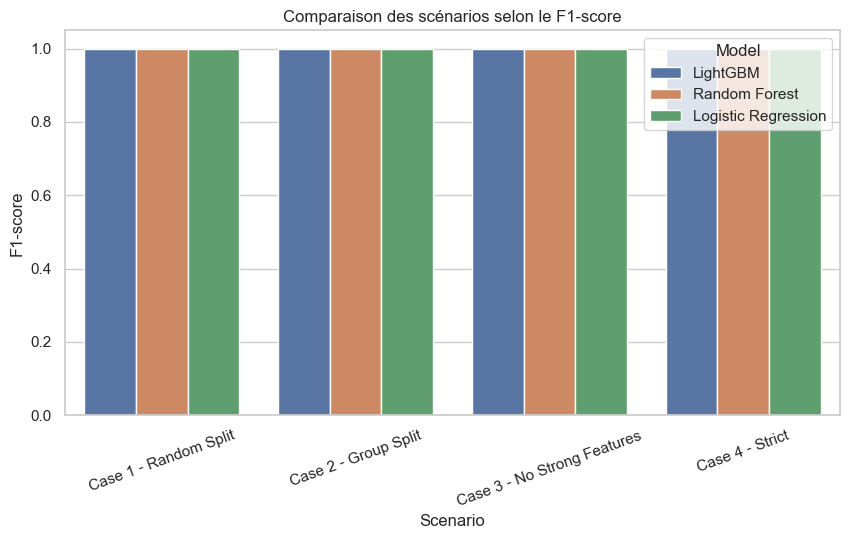

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Scenario", y="F1-score", hue="Model")
plt.title("Comparaison des scénarios selon le F1-score")
plt.xticks(rotation=20)
plt.show()

### Conclusion intermédiaire

À ce stade, on retient le **cas 4** comme scénario final, car il est le plus réaliste :
- il retire les variables trop fortes ou difficiles à reproduire en temps réel ;
- il impose un split par domaine, ce qui réduit le risque de fuite d'information ;
- il est le plus cohérent avec une future application réelle.

## 8. Cross-validation sur le cas 4

In [ ]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_cv = build_models(X_case4)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results_list = []

for model_name, model in models_cv.items():
    print("Cross-validation :", model_name)

    scores = cross_validate(
        model,
        X_case4,
        y_case4,
        groups=groups_case4,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_list.append({
        "Model": model_name,
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Accuracy_std": scores["test_accuracy"].std(),
        "Precision_mean": scores["test_precision"].mean(),
        "Recall_mean": scores["test_recall"].mean(),
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "PR_AUC_mean": scores["test_pr_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results_list).sort_values(by="F1_mean", ascending=False).reset_index(drop=True)
cv_results_df

Cross-validation : Logistic Regression


## 9. Entraînement du modèle final sur le cas 4

In [ ]:
models_case4 = build_models(X_train_case4)
final_model = models_case4["LightGBM"]

final_model.fit(X_train_case4, y_train_case4)

y_pred_base = final_model.predict(X_test_case4)
y_prob_base = final_model.predict_proba(X_test_case4)[:, 1]

print("===== Évaluation finale du modèle de base sur le test strict =====")
print("Accuracy :", accuracy_score(y_test_case4, y_pred_base))
print("Precision:", precision_score(y_test_case4, y_pred_base, zero_division=0))
print("Recall   :", recall_score(y_test_case4, y_pred_base, zero_division=0))
print("F1-score :", f1_score(y_test_case4, y_pred_base, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test_case4, y_prob_base))
print("PR-AUC   :", average_precision_score(y_test_case4, y_prob_base))

print("\n===== Classification Report =====")
print(classification_report(y_test_case4, y_pred_base, zero_division=0))

In [ ]:
plot_confusion_matrix(
    y_test_case4,
    y_pred_base,
    "Matrice de confusion - LightGBM de base (cas strict 4)"
)

In [ ]:
# Importance des variables du modèle de base
lgbm_model_base = final_model.named_steps["model"]
preprocessor_base = final_model.named_steps["preprocessor"]

feature_names_base = preprocessor_base.get_feature_names_out()

importance_df_base = pd.DataFrame({
    "Feature": feature_names_base,
    "Importance": lgbm_model_base.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df_base.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df_base.head(20), x="Importance", y="Feature")
plt.title("Top 20 des variables les plus importantes - modèle de base")
plt.show()

## 10. Optimisation du modèle final

In [ ]:
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv_tuning = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

random_search.fit(X_train_case4, y_train_case4, groups=groups_train_case4)

print("Best params :", random_search.best_params_)
print("Best F1 CV  :", random_search.best_score_)

In [ ]:
best_lgbm_model = random_search.best_estimator_

y_pred_tuned = best_lgbm_model.predict(X_test_case4)
y_prob_tuned = best_lgbm_model.predict_proba(X_test_case4)[:, 1]

print("===== LightGBM tuné - Test strict =====")
print("Accuracy :", accuracy_score(y_test_case4, y_pred_tuned))
print("Precision:", precision_score(y_test_case4, y_pred_tuned, zero_division=0))
print("Recall   :", recall_score(y_test_case4, y_pred_tuned, zero_division=0))
print("F1-score :", f1_score(y_test_case4, y_pred_tuned, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test_case4, y_prob_tuned))
print("PR-AUC   :", average_precision_score(y_test_case4, y_prob_tuned))

print("\n===== Classification Report =====")
print(classification_report(y_test_case4, y_pred_tuned, zero_division=0))

In [ ]:
plot_confusion_matrix(
    y_test_case4,
    y_pred_tuned,
    "Matrice de confusion - LightGBM tuné (cas strict 4)"
)

In [ ]:
comparison_final = pd.DataFrame([
    {
        "Version": "LightGBM de base",
        "Accuracy": accuracy_score(y_test_case4, y_pred_base),
        "Precision": precision_score(y_test_case4, y_pred_base, zero_division=0),
        "Recall": recall_score(y_test_case4, y_pred_base, zero_division=0),
        "F1-score": f1_score(y_test_case4, y_pred_base, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_case4, y_prob_base),
        "PR-AUC": average_precision_score(y_test_case4, y_prob_base)
    },
    {
        "Version": "LightGBM tuné",
        "Accuracy": accuracy_score(y_test_case4, y_pred_tuned),
        "Precision": precision_score(y_test_case4, y_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test_case4, y_pred_tuned, zero_division=0),
        "F1-score": f1_score(y_test_case4, y_pred_tuned, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_case4, y_prob_tuned),
        "PR-AUC": average_precision_score(y_test_case4, y_prob_tuned)
    }
])

comparison_final

Le choix final repose sur plusieurs critères :

1. **robustesse méthodologique** : le cas 4 impose un split par domaine, ce qui limite les fuites d'information ;
2. **compatibilité avec le déploiement** : les colonnes de `SUSPECT_COLS` sont retirées pour éviter des features difficiles à recalculer en temps réel ;
3. **performance** : LightGBM fournit de très bonnes métriques tout en restant rapide à entraîner et à réutiliser ;
4. **simplicité d'intégration** : le pipeline sauvegardé peut être directement rechargé dans le futur backend.

In [ ]:
lgbm_model_tuned = best_lgbm_model.named_steps["model"]
preprocessor_tuned = best_lgbm_model.named_steps["preprocessor"]

feature_names_tuned = preprocessor_tuned.get_feature_names_out()

importance_df_tuned = pd.DataFrame({
    "Feature": feature_names_tuned,
    "Importance": lgbm_model_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df_tuned.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df_tuned.head(20), x="Importance", y="Feature")
plt.title("Top 20 des variables les plus importantes - modèle tuné")
plt.show()

## 11. Sauvegarde des artefacts du modèle final

In [ ]:
os.makedirs("artifacts", exist_ok=True)

input_features = X_case4.columns.tolist()

metadata = {
    "model_name": "LightGBM Tuned",
    "training_case": "strict_case_4",
    "target_column": TARGET_COL,
    "n_input_features": len(input_features),
    "input_features": input_features,
    "excluded_features": SUSPECT_COLS,
    "best_params": random_search.best_params_
}

joblib.dump(best_lgbm_model, "artifacts/phishing_model.joblib")
joblib.dump(input_features, "artifacts/input_features.joblib")

with open("artifacts/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Sauvegarde terminée avec succès.")
print("- artifacts/phishing_model.joblib")
print("- artifacts/input_features.joblib")
print("- artifacts/metadata.json")

## 12. Test de rechargement

In [ ]:
loaded_model = joblib.load("artifacts/phishing_model.joblib")
loaded_features = joblib.load("artifacts/input_features.joblib")

with open("artifacts/metadata.json", "r", encoding="utf-8") as f:
    loaded_metadata = json.load(f)

print("Rechargement réussi.")
print("Nom du modèle :", loaded_metadata["model_name"])
print("Cas d'entraînement :", loaded_metadata["training_case"])
print("Nombre de features :", len(loaded_features))
print("Premières features :", loaded_features[:5])